<a href="https://colab.research.google.com/github/PayalJain-05/global-health-data-analysis/blob/main/Global_Health_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_excel('world_health_data.xlsx')
df.head()

,country,country_code,year,health_exp,life_expect,maternal_mortality,infant_mortality,neonatal_mortality,under_5_mortality,prev_hiv,inci_tuberc,prev_undernourishment
0,Aruba,ABW,1999,NaN,73.561000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,1999,NaN,51.258874,NaN,88.285642,38.433841,142.506373,6.684793,NaN,NaN
2,Afghanistan,AFG,1999,NaN,54.846000,NaN,94.600000,64.000000,135.800000,0.100000,NaN,NaN
3,Africa Western and Central,AFW,1999,NaN,49.726429,NaN,101.541373,44.733554,173.943151,NaN,NaN,NaN
4,Angola,AGO,1999,NaN,45.386000,NaN,123.500000,51.000000,208.000000,1.300000,NaN,NaN


In [ ]:
df.info()
df.columns
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6650 entries, 0 to 6649
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   country                6650 non-null   object 
 1   country_code           6650 non-null   object 
 2   year                   6650 non-null   int64  
 3   health_exp             5167 non-null   float64
 4   life_expect            6190 non-null   float64
 5   maternal_mortality     4893 non-null   float64
 6   infant_mortality       5856 non-null   float64
 7   neonatal_mortality     5856 non-null   float64
 8   under_5_mortality      5856 non-null   float64
 9   prev_hiv               4270 non-null   float64
 10  inci_tuberc            5429 non-null   float64
 11  prev_undernourishment  4805 non-null   float64
dtypes: float64(9), int64(1), object(2)
memory usage: 623.6+ KB


,year,health_exp,life_expect,maternal_mortality,infant_mortality,neonatal_mortality,under_5_mortality,prev_hiv,inci_tuberc,prev_undernourishment
count,6650.000000,5167.000000,6190.000000,4893.000000,5856.000000,5856.000000,5856.000000,4270.000000,5429.000000,4805.000000
mean,2011.000000,6.200581,70.066531,200.862661,28.966389,16.410860,40.399681,1.806485,126.391393,11.102418
std,7.211645,2.790519,8.667172,266.880355,25.493757,12.624923,40.898593,4.007134,179.738222,10.534553
min,1999.000000,1.107200,41.957000,1.000000,1.300000,0.700000,1.500000,0.100000,0.000000,2.500000
25%,2005.000000,4.246770,64.439894,18.000000,8.400000,5.200000,9.900000,0.100000,14.000000,2.631544
50%,2011.000000,5.443990,71.839268,74.000000,20.100000,12.700000,23.606879,0.400000,51.000000,7.100000
75%,2017.000000,7.790887,76.612000,297.000000,44.400000,25.700000,60.100000,1.500000,177.000000,15.965738
max,2023.000000,24.283052,85.532683,1687.000000,140.800000,64.000000,237.500000,29.900000,1590.000000,71.400000


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df.isnull().sum()

df.fillna(method='ffill', inplace=True)

df.rename(columns=lambda x: x.strip(), inplace=True)

/tmp/ipykernel_1404/802175119.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_excel('world_health_data.xlsx') # Reload df to ensure 'country' column is present

df.columns = df.columns.str.strip()
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(" ", "_")

# 3. Remove duplicate rows
df = df.drop_duplicates()

# 4. Check missing values
print(df.isnull().sum())

# 5. Convert data types
df['year'] = pd.to_numeric(df['year'], errors='coerce')

# Convert other numeric columns (manually if needed)
# Example:
# df['life_expectancy'] = pd.to_numeric(df['life_expectancy'], errors='coerce')

# 6. Sort data (important for time-based filling)
df = df.sort_values(by=['country', 'year'])

# Identify columns to fill (all except 'country' and 'country_code')
cols_to_fill = [col for col in df.columns if col not in ['country', 'country_code']]

# 7. Forward fill missing values (within each country)
df[cols_to_fill] = df.groupby('country')[cols_to_fill].ffill()

# 8. Backward fill (extra safety)
df[cols_to_fill] = df.groupby('country')[cols_to_fill].bfill()

# 9. Fill remaining numeric missing values with median
numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# 10. Fill categorical missing values with mode
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# 11. Remove outliers using IQR
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

# 12. Reset index
df = df.reset_index(drop=True)

# 13. Final check
print(df.info())
print(df.isnull().sum())


country                     0
country_code                0
year                        0
health_exp               1483
life_expect               460
maternal_mortality       1757
infant_mortality          794
neonatal_mortality        794
under_5_mortality         794
prev_hiv                 2380
inci_tuberc              1221
prev_undernourishment    1845
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3748 entries, 0 to 3747
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   country                3748 non-null   object 
 1   country_code           3748 non-null   object 
 2   year                   3748 non-null   int64  
 3   health_exp             3748 non-null   float64
 4   life_expect            3748 non-null   float64
 5   maternal_mortality     3748 non-null   float64
 6   infant_mortality       3748 non-null   float64
 7   neonatal_mortality     3748 non-null   float64


In [ ]:
print(df['country'].nunique())
print(df['year'].nunique())

172
25


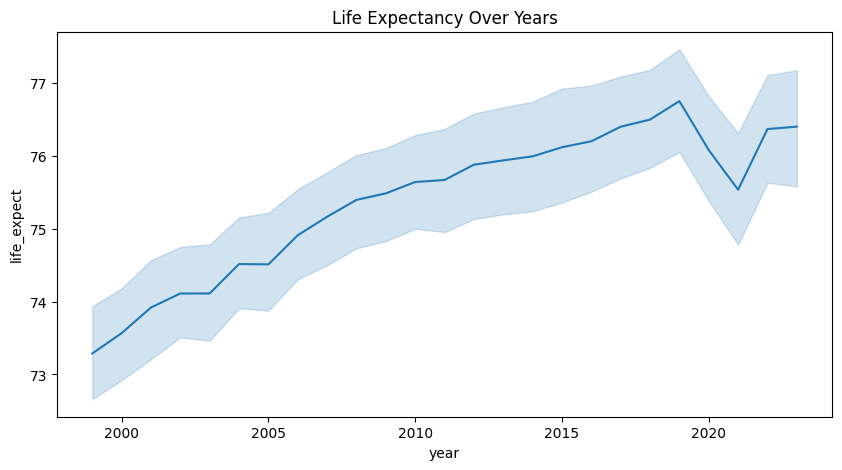

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.lineplot(data=df, x='year', y='life_expect')
plt.title("Life Expectancy Over Years")
plt.show()

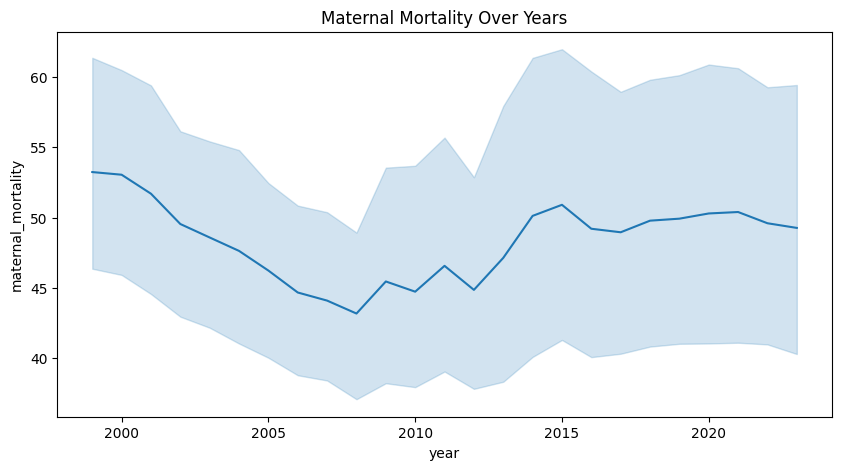

In [ ]:
plt.figure(figsize=(10,5))
sns.lineplot(data=df, x='year', y='maternal_mortality')
plt.title("Maternal Mortality Over Years")
plt.show()

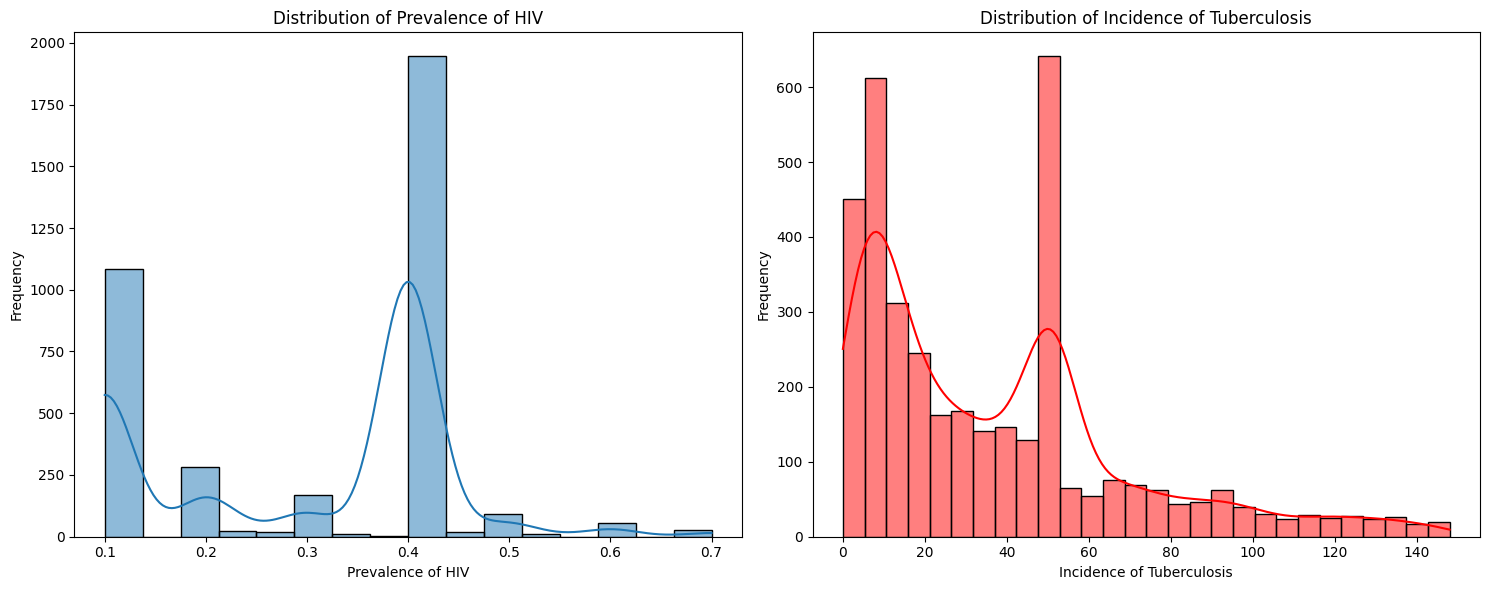

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(data=df, x='prev_hiv', kde=True, ax=axes[0])
axes[0].set_title('Distribution of Prevalence of HIV')
axes[0].set_xlabel('Prevalence of HIV')
axes[0].set_ylabel('Frequency')

sns.histplot(data=df, x='inci_tuberc', kde=True, ax=axes[1], color='red')
axes[1].set_title('Distribution of Incidence of Tuberculosis')
axes[1].set_xlabel('Incidence of Tuberculosis')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
top = df.groupby('country')['life_expect'].mean().nlargest(5)
bottom = df.groupby('country')['life_expect'].mean().nsmallest(5)

print(top)
print(bottom)

country
Macao SAR, China        84.118059
Hong Kong SAR, China    83.114371
Japan                   82.945259
Switzerland             82.198341
Cayman Islands          82.168585
Name: life_expect, dtype: float64
country
Nauru         60.724500
Comoros       63.488571
Tuvalu        63.836000
Guyana        64.480333
Mauritania    64.697909
Name: life_expect, dtype: float64


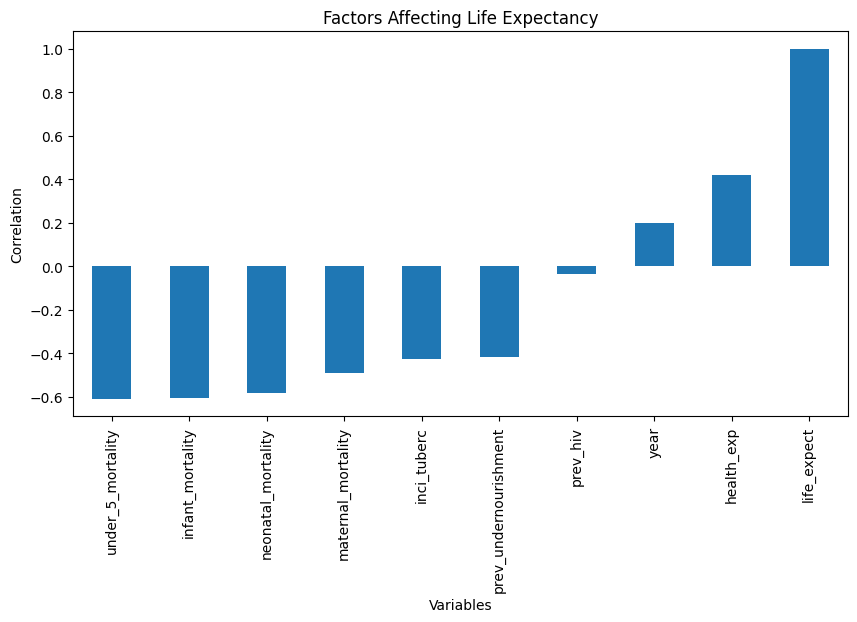

In [ ]:
corr = df.corr(numeric_only=True)['life_expect'].sort_values()

corr.plot(kind='bar', figsize=(10,5))

plt.title("Factors Affecting Life Expectancy")
plt.xlabel("Variables")
plt.ylabel("Correlation")
plt.show()

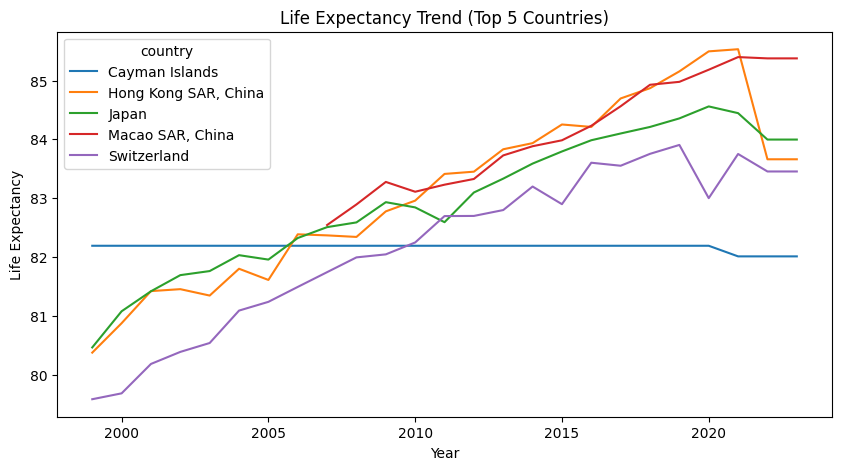

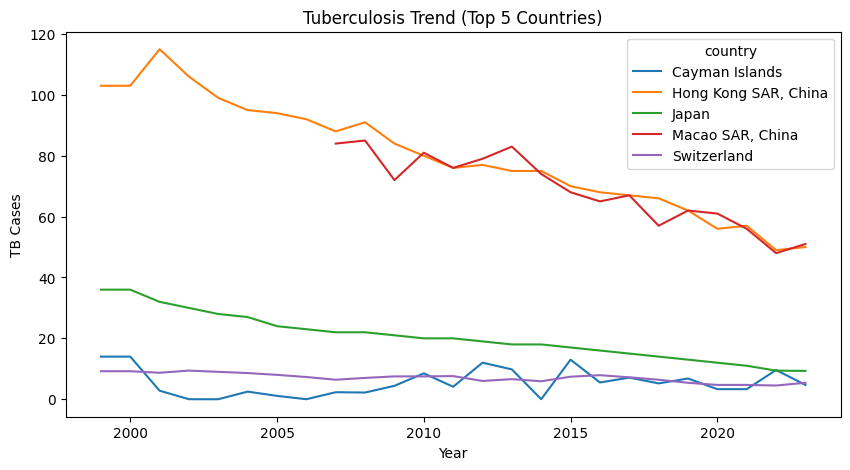

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Get Top 5 Countries (by Life Expectancy)
# -----------------------------
top5_countries = df.groupby('country')['life_expect'].mean().nlargest(5).index

# -----------------------------
# 2. Filter dataset
# -----------------------------
top5_df = df[df['country'].isin(top5_countries)]

# -----------------------------
# 3. Life Expectancy Trend
# -----------------------------
plt.figure(figsize=(10,5))
sns.lineplot(data=top5_df, x='year', y='life_expect', hue='country')

plt.title("Life Expectancy Trend (Top 5 Countries)")
plt.xlabel("Year")
plt.ylabel("Life Expectancy")
plt.show()

# -----------------------------
# 5. Tuberculosis Trend
# -----------------------------
plt.figure(figsize=(10,5))
sns.lineplot(data=top5_df, x='year', y='inci_tuberc', hue='country')

plt.title("Tuberculosis Trend (Top 5 Countries)")
plt.xlabel("Year")
plt.ylabel("TB Cases")
plt.show()




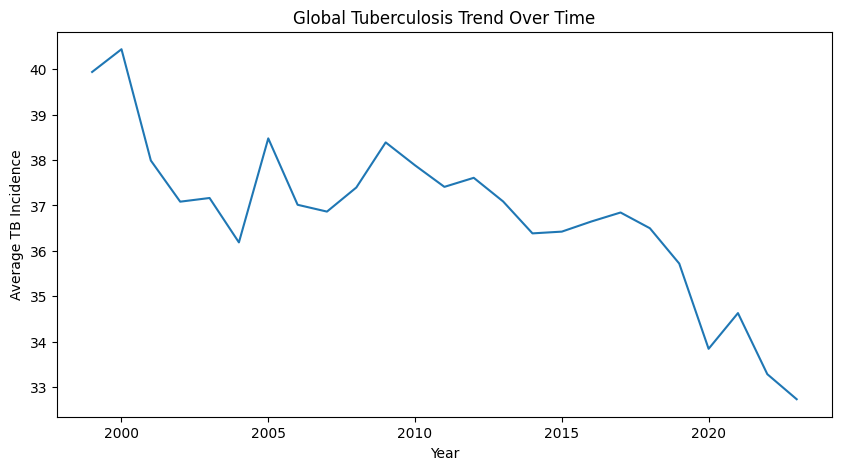

In [ ]:
year_tb = df.groupby('year')['inci_tuberc'].mean()

year_tb.plot(figsize=(10,5))

plt.title("Global Tuberculosis Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Average TB Incidence")
plt.show()

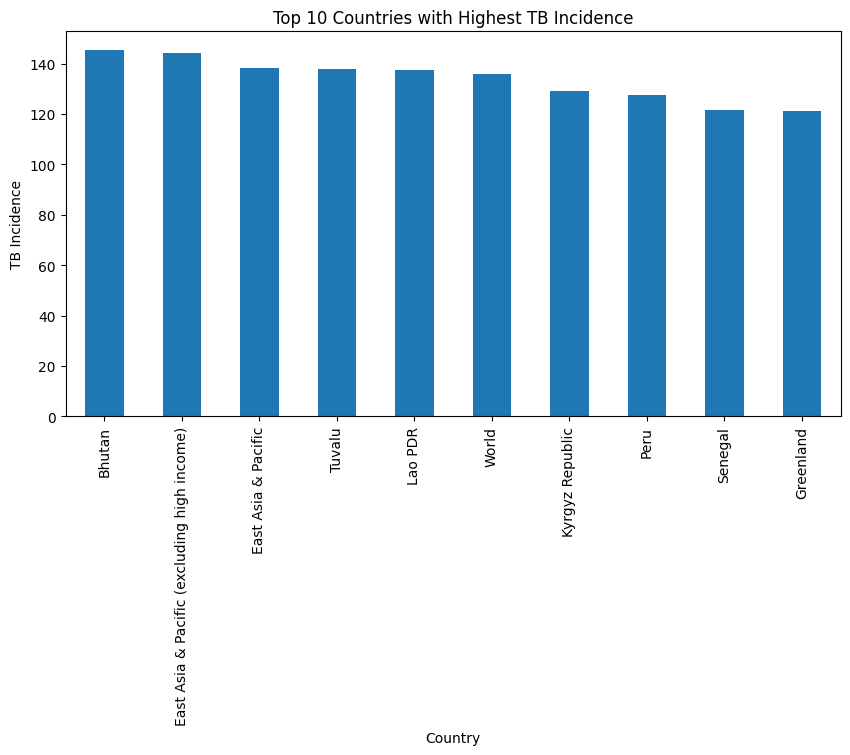

In [ ]:
top_tb = df.groupby('country')['inci_tuberc'].mean().nlargest(10)

top_tb.plot(kind='bar', figsize=(10,5))

plt.title("Top 10 Countries with Highest TB Incidence")
plt.xlabel("Country")
plt.ylabel("TB Incidence")
plt.show()

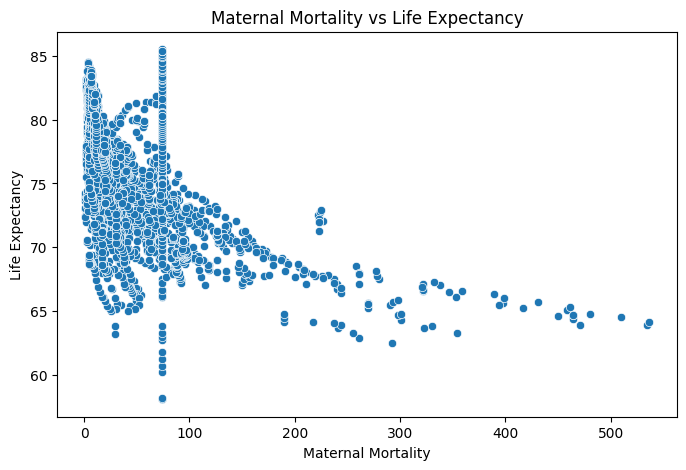

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='maternal_mortality', y='life_expect')

plt.title("Maternal Mortality vs Life Expectancy")
plt.xlabel("Maternal Mortality")
plt.ylabel("Life Expectancy")
plt.show()

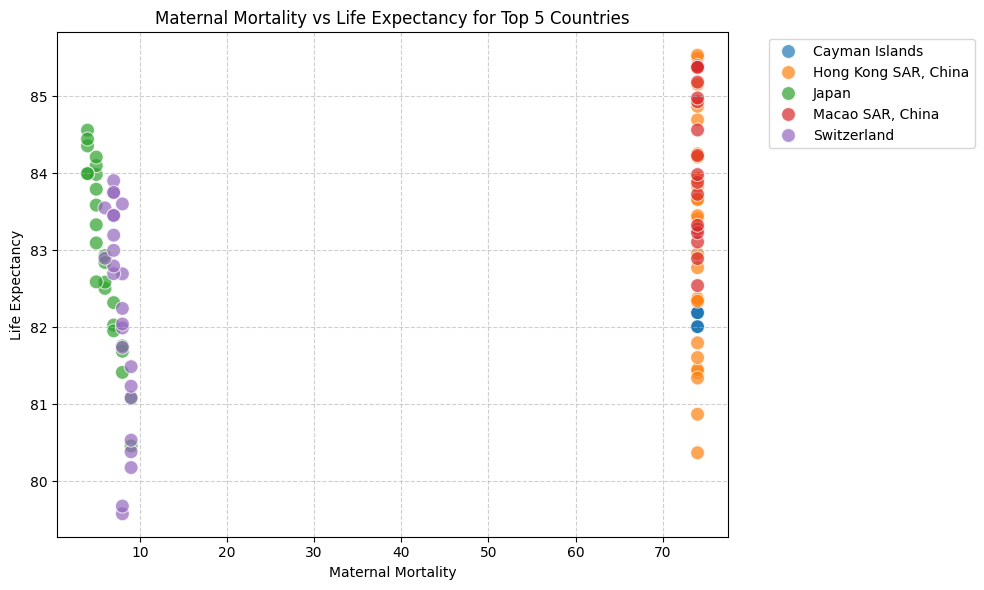

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=top5_df, x='maternal_mortality', y='life_expect', hue='country', s=100, alpha=0.7)
plt.title('Maternal Mortality vs Life Expectancy for Top 5 Countries')
plt.xlabel('Maternal Mortality')
plt.ylabel('Life Expectancy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

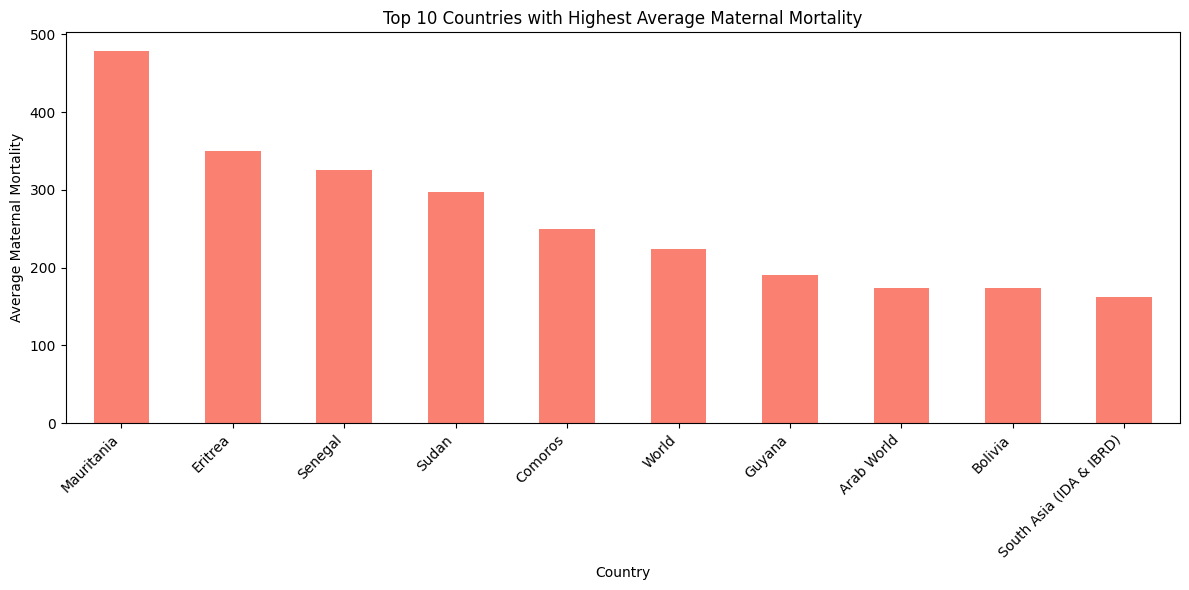

In [ ]:
top_mm_countries = df.groupby('country')['maternal_mortality'].mean().nlargest(10)

plt.figure(figsize=(12, 6))
top_mm_countries.plot(kind='bar', color='salmon')
plt.title('Top 10 Countries with Highest Average Maternal Mortality')
plt.xlabel('Country')
plt.ylabel('Average Maternal Mortality')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

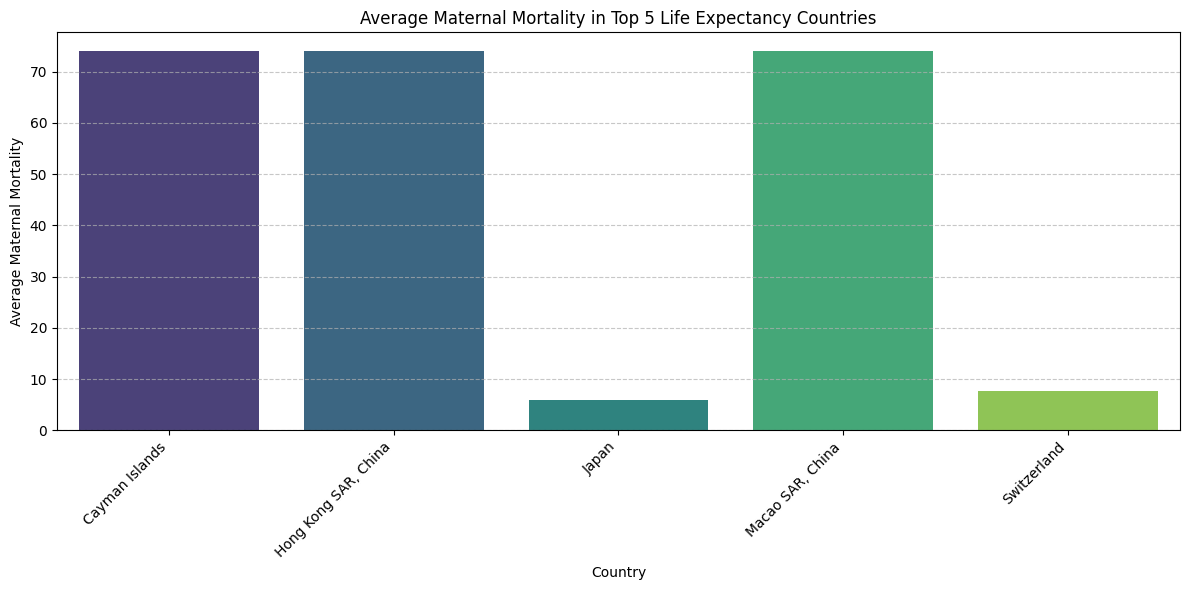

In [ ]:
plt.figure(figsize=(12, 6))
avg_maternal_mortality = top5_df.groupby('country')['maternal_mortality'].mean().reset_index()
sns.barplot(data=avg_maternal_mortality, x='country', y='maternal_mortality', hue='country', palette='viridis', legend=False)
plt.title('Average Maternal Mortality in Top 5 Life Expectancy Countries')
plt.xlabel('Country')
plt.ylabel('Average Maternal Mortality')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()